# **Project Name**    - Mutual Fund Performance & Risk Analytics



##### **Project Type**    - EDA
##### **Contribution**    - Individual

# **Project Summary -**

Mutual Fund Analysis is an end-to-end data analytics project designed to evaluate mutual funds based on returns, risk, cost, fund size, ratings, and risk-adjusted performance. The objective was to help investors and investment teams compare funds and identify potentially attractive schemes using a data-driven approach.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


Mutual fund investors face difficulty in comparing hundreds of schemes based on returns, risk, cost, AUM, and risk-adjusted performance. A data-driven solution is needed to evaluate and compare funds and identify potentially suitable investment options.

#### **Define Your Business Objective?**

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

### Dataset Loading

In [2]:
# Load Dataset
df = pd.read_csv("C:/Users/Harika challa/Innovexis/Project-12/comprehensive_mutual_funds_data.csv")

### Dataset First View

In [3]:
# Dataset First Look
df.head()

,scheme_name,min_sip,min_lumpsum,expense_ratio,fund_size_cr,fund_age_yr,fund_manager,sortino,alpha,sd,beta,sharpe,risk_level,amc_name,rating,category,sub_category,returns_1yr,returns_3yr,returns_5yr
0,Aditya Birla SL Active Debt Multi-Mgr FoF-Dir ...,100,100,0.27,10.0,10,Kaustubh Gupta,0.32,2.24,9.39,0.01,0.24,3,Aditya Birla Sun Life Mutual Fund,3,Other,FoFs Domestic,4.0,6.5,6.9
1,Aditya Birla SL Arbitrage Fund,1000,1000,0.36,4288.0,10,Lovelish Solanki,1.33,1.53,0.72,0.56,1.1,1,Aditya Birla Sun Life Mutual Fund,3,Hybrid,Arbitrage Mutual Funds,5.6,4.8,5.5
2,Aditya Birla SL Asset Allocator FoF-Dir Growth,1000,1000,0.53,157.0,10,Vinod Narayan Bhat,3.44,2.67,10.58,0.67,1.42,5,Aditya Birla Sun Life Mutual Fund,3,Other,FoFs Domestic,2.0,18.9,9.7
3,Aditya Birla SL Bal Bhavishya Yojna – Dir Growth,500,1000,0.76,637.0,4,Atul Penkar,2.18,-6.37,14.99,0.85,0.9,6,Aditya Birla Sun Life Mutual Fund,2,Solution Oriented,Childrens Funds,-0.7,17.1,NaN
4,Aditya Birla SL Balanced Advantage Fund,100,100,0.61,6386.0,10,Mohit Sharma,3.69,1.99,10.38,0.68,1.39,6,Aditya Birla Sun Life Mutual Fund,4,Hybrid,Dynamic Asset Allocation or Balanced Advantage,4.5,18.6,9.7


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


Shape: (814, 20)

Columns:
['scheme_name', 'min_sip', 'min_lumpsum', 'expense_ratio', 'fund_size_cr', 'fund_age_yr', 'fund_manager', 'sortino', 'alpha', 'sd', 'beta', 'sharpe', 'risk_level', 'amc_name', 'rating', 'category', 'sub_category', 'returns_1yr', 'returns_3yr', 'returns_5yr']


### Dataset Information

In [5]:
# Dataset Info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 814 entries, 0 to 813
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   scheme_name    814 non-null    object 
 1   min_sip        814 non-null    int64  
 2   min_lumpsum    814 non-null    int64  
 3   expense_ratio  814 non-null    float64
 4   fund_size_cr   814 non-null    float64
 5   fund_age_yr    814 non-null    int64  
 6   fund_manager   814 non-null    object 
 7   sortino        814 non-null    object 
 8   alpha          814 non-null    object 
 9   sd             814 non-null    object 
 10  beta           814 non-null    object 
 11  sharpe         814 non-null    object 
 12  risk_level     814 non-null    int64  
 13  amc_name       814 non-null    object 
 14  rating         814 non-null    int64  
 15  category       814 non-null    object 
 16  sub_category   814 non-null    object 
 17  returns_1yr    814 non-null    float64
 18  returns_3y

#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
print("Duplicate Values:")
print(df.duplicated().sum())


Duplicate Values:
0


#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
scheme_name        0
min_sip            0
min_lumpsum        0
expense_ratio      0
fund_size_cr       0
fund_age_yr        0
fund_manager       0
sortino            0
alpha              0
sd                 0
beta               0
sharpe             0
risk_level         0
amc_name           0
rating             0
category           0
sub_category       0
returns_1yr        0
returns_3yr       21
returns_5yr      167
dtype: int64


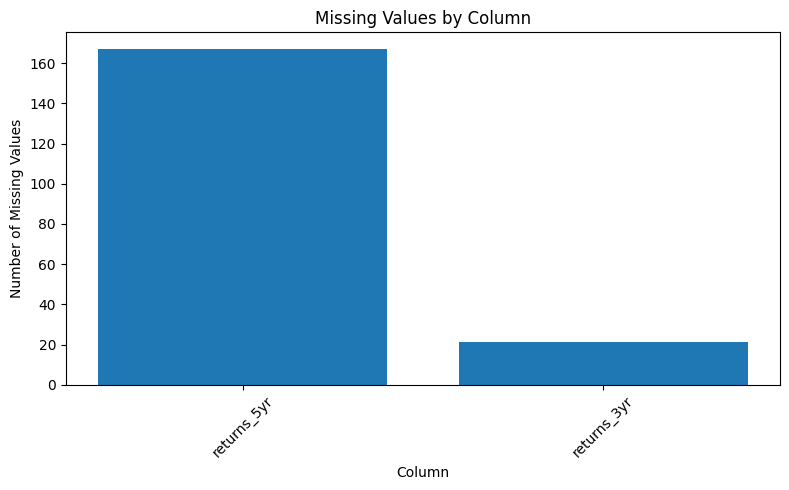

In [8]:
# Visualizing the missing values
import matplotlib.pyplot as plt

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(missing.index, missing.values)
plt.title("Missing Values by Column")
plt.xlabel("Column")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### What did you know about your dataset?

My dataset contains 814 mutual fund records and 20 variables. Each row represents a mutual fund scheme, while the columns contain information about investment requirements, fund size, fund manager, risk and performance metrics, AMC, ratings, category and sub-category.

From the initial data profiling, I found that the dataset has 789 unique scheme names, 39 AMCs, 5 major fund categories and 38 sub-categories. The dataset contains both numerical and categorical variables.

The main performance variables are 1-year, 3-year and 5-year returns. Risk and performance are also represented through metrics such as Sharpe, Sortino, Alpha, Standard Deviation and Beta. Cost is represented by expense ratio, while fund size is represented by AUM in crore.

From the data-quality assessment, I found 188 missing values, mainly in the longer-term return fields, particularly 3-year and 5-year returns. I also found that some risk metrics such as Sharpe, Sortino, Alpha, SD and Beta were stored as object/text values instead of numeric values, so these require cleaning before analysis.

The dataset therefore provides enough information to evaluate mutual funds based on return, risk, cost, fund characteristics and investment requirements, which supports the objective of identifying high-return, relatively lower-cost and consistently performing funds.

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
print("Columns:")
print(df.columns.tolist())

Columns:
['scheme_name', 'min_sip', 'min_lumpsum', 'expense_ratio', 'fund_size_cr', 'fund_age_yr', 'fund_manager', 'sortino', 'alpha', 'sd', 'beta', 'sharpe', 'risk_level', 'amc_name', 'rating', 'category', 'sub_category', 'returns_1yr', 'returns_3yr', 'returns_5yr']


In [10]:
# Dataset Describe
print("Dataset Description:")
print(df.describe())

Dataset Description:
           min_sip   min_lumpsum  expense_ratio  fund_size_cr  fund_age_yr  \
count   814.000000    814.000000     814.000000    814.000000   814.000000   
mean    528.500000   3047.468059       0.713231   3812.854214     8.319410   
std     369.184517   2514.619513       0.482161   7181.479475     2.640622   
min       0.000000      0.000000       0.000000      2.380000     1.000000   
25%     150.000000    500.000000       0.310000    175.250000     6.000000   
50%     500.000000   5000.000000       0.615000    940.500000    10.000000   
75%    1000.000000   5000.000000       1.030000   3819.000000    10.000000   
max    2000.000000  25000.000000       2.590000  57052.000000    17.000000   

       risk_level      rating  returns_1yr  returns_3yr  returns_5yr  
count  814.000000  814.000000   814.000000   793.000000   647.000000  
mean     4.400491    2.641278     3.921376    18.525347     9.490726  
std      1.814741    1.463476     6.675502    12.108476     3.7

### Variables Description

| Business Area            | Variables                                                |
| ------------------------ | -------------------------------------------------------- |
| **Identification**       | `scheme_name`                                            |
| **Investment**           | `min_sip`, `min_lumpsum`                                 |
| **Cost & AUM**           | `expense_ratio`, `fund_size_cr`                          |
| **Fund Characteristics** | `fund_age_yr`, `fund_manager`                            |
| **Risk Metrics**         | `risk_level`, `sortino`, `sd`, `beta`, `sharpe`, `alpha` |
| **Organization**         | `amc_name`                                               |
| **Classification**       | `rating`, `category`, `sub_category`                     |
| **Performance**          | `returns_1yr`, `returns_3yr`, `returns_5yr`              |


### Check Unique Values for each variable.

In [11]:
# Check Unique Values for each variable.
print("Unique Values:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")
    

Unique Values:
scheme_name: 789 unique values
min_sip: 10 unique values
min_lumpsum: 11 unique values
expense_ratio: 177 unique values
fund_size_cr: 693 unique values
fund_age_yr: 14 unique values
fund_manager: 260 unique values
sortino: 385 unique values
alpha: 540 unique values
sd: 581 unique values
beta: 162 unique values
sharpe: 217 unique values
risk_level: 6 unique values
amc_name: 39 unique values
rating: 6 unique values
category: 5 unique values
sub_category: 38 unique values
returns_1yr: 210 unique values
returns_3yr: 304 unique values
returns_5yr: 147 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# Write your code to make your dataset analysis ready.

#CLEAN COLUMN NAMES
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)


In [13]:
#Columns after cleaning
df.columns

Index(['scheme_name', 'min_sip', 'min_lumpsum', 'expense_ratio',
       'fund_size_cr', 'fund_age_yr', 'fund_manager', 'sortino', 'alpha', 'sd',
       'beta', 'sharpe', 'risk_level', 'amc_name', 'rating', 'category',
       'sub_category', 'returns_1yr', 'returns_3yr', 'returns_5yr'],
      dtype='object')

In [14]:
#CONVERT RISK/PERFORMANCE COLUMNS TO NUMERIC
numeric_columns = [
    "min_sip",
    "min_lumpsum",
    "expense_ratio",
    "fund_size_cr",
    "fund_age_yr",
    "sortino",
    "alpha",
    "sd",
    "beta",
    "sharpe",
    "risk_level",
    "rating",
    "returns_1yr",
    "returns_3yr",
    "returns_5yr"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


In [15]:
#checking the data types after conversion
df.dtypes

scheme_name       object
min_sip            int64
min_lumpsum        int64
expense_ratio    float64
fund_size_cr     float64
fund_age_yr        int64
fund_manager      object
sortino          float64
alpha            float64
sd               float64
beta             float64
sharpe           float64
risk_level         int64
amc_name          object
rating             int64
category          object
sub_category      object
returns_1yr      float64
returns_3yr      float64
returns_5yr      float64
dtype: object

In [16]:
# Convert fund_size_cr to integer
df["fund_size_cr"] = df["fund_size_cr"].astype(int)

#convert fund_age_yr to integer
print(df["fund_size_cr"].dtype)

int64


In [17]:
missing_summary = (
    df.isnull()
    .sum()
    .reset_index()
)

missing_summary.columns = ["column", "missing_count"]

missing_summary["missing_percentage"] = (
    missing_summary["missing_count"]
    / len(df) * 100
).round(2)

print("\nMissing Values:")
print(
    missing_summary[
        missing_summary["missing_count"] > 0
    ]
)


Missing Values:
         column  missing_count  missing_percentage
7       sortino             23                2.83
8         alpha             42                5.16
9            sd             24                2.95
10         beta             42                5.16
11       sharpe             23                2.83
18  returns_3yr             21                2.58
19  returns_5yr            167               20.52


In [18]:
#Handling missing values
risk_columns = [
    "sortino",
    "alpha",
    "sd",
    "beta",
    "sharpe"
]

for col in risk_columns:
    df[col] = df[col].fillna(df[col].median())

In [19]:
#Verifying missing values after handling
missing_summary_after = df[risk_columns].isnull().sum()
print("Missing values after handling:")
print(missing_summary_after)

Missing values after handling:
sortino    0
alpha      0
sd         0
beta       0
sharpe     0
dtype: int64


In [20]:
#Handling missing values for returns columns
df["returns_3yr"].isnull().sum()

np.int64(21)

In [21]:
df["returns_5yr"].isnull().sum()

np.int64(167)

In [22]:
# Create dataset for fund scoring
scoring_df = df.dropna(
    subset=["returns_3yr"]
).copy()

In [23]:
# Fill categorical missing values
categorical_columns = [
    "scheme_name",
    "fund_manager",
    "risk_level",
    "amc_name",
    "category",
    "sub_category"
]

for col in categorical_columns:
    df[col] = df[col].fillna("Unknown")

print("\nShape After Cleaning:", df.shape)


Shape After Cleaning: (814, 20)


In [24]:
 # STANDARDIZE TEXT COLUMNS
for col in categorical_columns:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
    )

In [25]:
#CHECK INVALID VALUES
print("\nInvalid Negative Values:")

print(
    "min_sip:",
    (df["min_sip"] < 0).sum()
)

print(
    "min_lumpsum:",
    (df["min_lumpsum"] < 0).sum()
)

print(
    "expense_ratio:",
    (df["expense_ratio"] < 0).sum()
)

print(
    "fund_size_cr:",
    (df["fund_size_cr"] < 0).sum()
)

print(
    "fund_age_yr:",
    (df["fund_age_yr"] < 0).sum()
)


Invalid Negative Values:
min_sip: 0
min_lumpsum: 0
expense_ratio: 0
fund_size_cr: 0
fund_age_yr: 0


In [26]:
#CREATE ANALYSIS FLAGS

# Positive 1-year return
df["positive_1yr_return"] = np.where(
    df["returns_1yr"] > 0,
    1,
    0
)

# Available 3-year return
df["has_3yr_return"] = np.where(
    df["returns_3yr"].notna(),
    1,
    0
)

# Available 5-year return
df["has_5yr_return"] = np.where(
    df["returns_5yr"].notna(),
    1,
    0
)

In [27]:
# Convert risk_level and rating to numeric
df["risk_level"] = pd.to_numeric(df["risk_level"], errors="coerce")
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")

In [28]:
numeric_columns = [
    "min_sip",
    "min_lumpsum",
    "expense_ratio",
    "fund_size_cr",
    "fund_age_yr",
    "sortino",
    "alpha",
    "sd",
    "beta",
    "sharpe",
    "risk_level",
    "rating",
    "returns_1yr",
    "returns_3yr",
    "returns_5yr"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [29]:
# 3. BASIC DATA UNDERSTANDING

print("\nStatistical Summary:")
print(df[numeric_columns].describe().T)

print("\nMedian:")
print(df[numeric_columns].median())

print("\nMode:")
print(df[numeric_columns].mode().iloc[0])

print("\nRisk Distribution:")
print(df["risk_level"].value_counts())

print("\nCategory Distribution:")
print(df["category"].value_counts())

print("\nAMC Distribution:")
print(df["amc_name"].value_counts().head(10))



Statistical Summary:
               count         mean          std    min       25%       50%  \
min_sip        814.0   528.500000   369.184517   0.00  150.0000   500.000   
min_lumpsum    814.0  3047.468059  2514.619513   0.00  500.0000  5000.000   
expense_ratio  814.0     0.713231     0.482161   0.00    0.3100     0.615   
fund_size_cr   814.0  3812.850123  7181.481645   2.00  175.2500   940.500   
fund_age_yr    814.0     8.319410     2.640622   1.00    6.0000    10.000   
sortino        814.0     2.658784     1.372866  -1.77    1.8100     2.870   
alpha          814.0     2.472064     3.850843 -13.36    0.5700     1.855   
sd             814.0    10.332469     7.697244   0.27    2.2225    12.300   
beta           814.0     0.824189     1.275615 -31.86    0.7100     0.860   
sharpe         814.0     1.206609     0.528980  -0.82    0.9325     1.290   
risk_level     814.0     4.400491     1.814741   1.00    3.0000     6.000   
rating         814.0     2.641278     1.463476   0.00 

In [30]:
# CATEGORICAL DISTRIBUTION


print("\n--- Risk Level Distribution ---")
print(df["risk_level"].value_counts().sort_index())

print("\n--- Category Distribution ---")
print(df["category"].value_counts())

print("\n--- Sub-Category Distribution ---")
print(df["sub_category"].value_counts())

print("\n--- Rating Distribution ---")
print(df["rating"].value_counts().sort_index())

print("\n--- AMC Distribution ---")


--- Risk Level Distribution ---
risk_level
1     53
2    127
3    124
4     65
5     27
6    418
Name: count, dtype: int64

--- Category Distribution ---
category
Equity               308
Debt                 282
Hybrid               116
Other                 80
Solution Oriented     28
Name: count, dtype: int64

--- Sub-Category Distribution ---
sub_category
Sectoral / Thematic Mutual Funds                  82
ELSS Mutual Funds                                 52
FoFs Domestic                                     35
Liquid Mutual Funds                               34
Aggressive Hybrid Mutual Funds                    30
Index Funds                                       30
Large Cap Mutual Funds                            28
Overnight Mutual Funds                            26
Ultra Short Duration Funds                        25
Small Cap Mutual Funds                            25
Large & Mid Cap Funds                             24
Short Duration Funds                              23
M

In [ ]:
# FINAL DATA QUALITY CHECK
print("\nFinal Shape:", df.shape)

print("\nFinal Data Types:")
print(df.dtypes)


Final Shape: (814, 23)

Final Data Types:
scheme_name             object
min_sip                  int64
min_lumpsum              int64
expense_ratio          float64
fund_size_cr             int64
fund_age_yr              int64
fund_manager            object
sortino                float64
alpha                  float64
sd                     float64
beta                   float64
sharpe                 float64
risk_level               int64
amc_name                object
rating                   int64
category                object
sub_category            object
returns_1yr            float64
returns_3yr            float64
returns_5yr            float64
positive_1yr_return      int64
has_3yr_return           int64
has_5yr_return           int64
dtype: object


In [32]:
print("\nFinal Missing Values:")
print(
    df.isnull()
    .sum()
    .sort_values(ascending=False)
)


Final Missing Values:
returns_5yr            167
returns_3yr             21
scheme_name              0
expense_ratio            0
fund_size_cr             0
min_sip                  0
min_lumpsum              0
fund_manager             0
fund_age_yr              0
sortino                  0
alpha                    0
sharpe                   0
risk_level               0
sd                       0
beta                     0
rating                   0
amc_name                 0
sub_category             0
category                 0
returns_1yr              0
positive_1yr_return      0
has_3yr_return           0
has_5yr_return           0
dtype: int64


In [33]:
 # SAVE ANALYSIS-READY DATASET
df.to_csv(
    "mutual_funds_analysis_ready.csv",
    index=False
)

print(
    "\nAnalysis-ready dataset saved as:"
    " mutual_funds_analysis_ready.csv"
)


Analysis-ready dataset saved as: mutual_funds_analysis_ready.csv


In [34]:
#Download the analysis-ready dataset
import os

print(os.getcwd())
print(os.path.abspath("mutual_funds_analysis_ready.csv"))

c:\Users\Harika challa\Innovexis
c:\Users\Harika challa\Innovexis\mutual_funds_analysis_ready.csv


### What all manipulations have you done and insights you found?

Initially, the dataset contained 188 explicit missing values in the 3-year and 5-year return columns. During data-type conversion, I identified additional non-numeric or invalid values in the risk metrics. Converting these object columns to numeric using errors='coerce' converted those invalid values into missing values. Therefore, the final missing-value assessment identified 342 missing values across seven columns.

I handled missing values based on the business meaning of each variable. For the risk metrics, which had a relatively small percentage of missing values, I used median imputation because these metrics can contain extreme values. I retained missing 3-year and 5-year returns instead of artificially imputing performance values. Since 3-year return is required for my fund scoring methodology, I excluded funds without a 3-year return from the scoring calculation

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 : DISTRIBUTION OF RETURNS

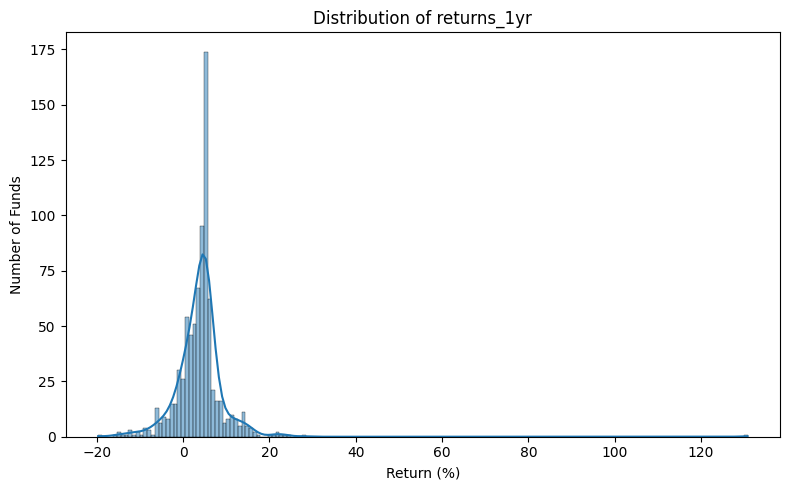

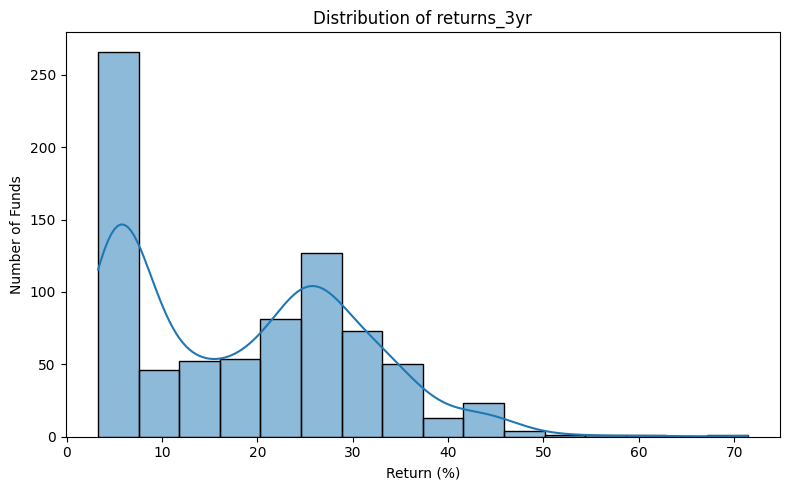

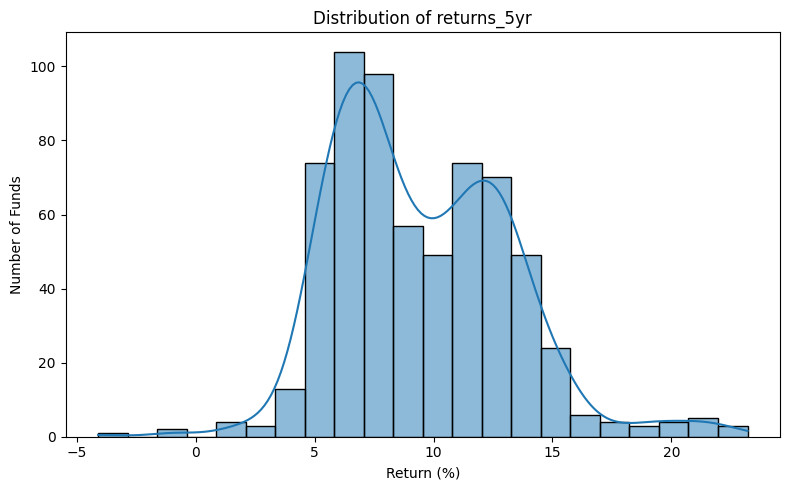

In [35]:
# Chart - 1 visualization code
return_columns = [
    "returns_1yr",
    "returns_3yr",
    "returns_5yr"
]

for col in return_columns:

    plt.figure(figsize=(8, 5))
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel("Return (%)")
    plt.ylabel("Number of Funds")
    plt.tight_layout()
    plt.show()

##### Distribution of 1YR Returns

##### 1. Why did you pick the specific chart?

A histogram is ideal for detecting skewness, concentration and outliers.

##### 2. What is/are the insight(s) found from the chart?

The 1-year return distribution is strongly right-skewed, with most funds clustered at relatively low returns and a few extreme high-return observations.

The maximum observed 1-year return is 130.8%.

Insights : 
Most funds have relatively moderate 1-year returns.
A few funds have exceptionally high returns.
The extreme values make the mean less representative of a typical fund.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive business impact :

This helps analysts avoid making decisions based only on the average return and encourages investigation of outlier funds.

Negative-growth implication : 

Short-term performance chasing can lead investors toward unusually high-risk funds and potentially result in poor outcomes if performance reverses.

##### Distribution of 3YR returns

##### 1. Why did you pick the specific chart?

A histogram allows us to see the shape, concentration and extreme values of 3-year returns.

##### 2. What is/are the insight(s) found from the chart?

3-year returns are concentrated around the lower-to-middle range, with a long upper tail extending toward approximately 71.4%.

Insights:
Most funds have moderate 3-year returns.
A relatively small number of funds generate exceptionally high returns.
The distribution is right-skewed.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive business impact:

Helps identify high-performing funds while also showing that exceptional performance is not representative of the entire fund universe.

Negative-growth implication:

Extreme high returns can distort averages and may lead to unrealistic expectations if investors assume these results are typical.

##### Distribution of 5-Year Returns

##### 1. Why did you pick the specific chart?

A histogram shows the overall performance distribution and helps identify skewness and unusual observations.

##### 2. What is/are the insight(s) found from the chart?

5-year returns are concentrated mostly in the lower-to-middle range, with relatively fewer funds at the higher end.

Insights:
Most funds have 5-year returns within a relatively narrow range.
Some funds have negative 5-year returns.
The dataset has substantial missing 5-year observations (167 funds).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive business impact :

Provides a realistic view of long-term performance across available funds.

Negative-growth implication:

The missing 5-year data limits long-term comparisons and can make some funds difficult to evaluate consistently.

#### Chart - 2 : DISTRIBUTION OF EXPENSE RATIO

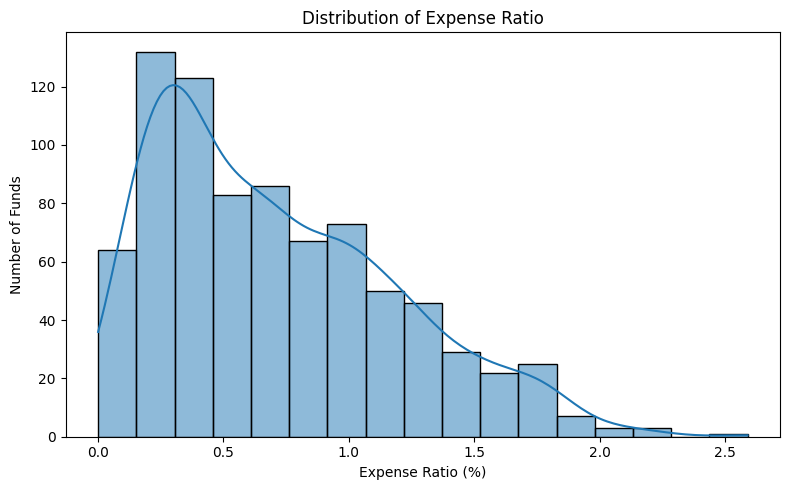

In [36]:
# Chart - 2 visualization code
plt.figure(figsize=(8, 5))
sns.histplot(df["expense_ratio"], kde=True)
plt.title("Distribution of Expense Ratio")
plt.xlabel("Expense Ratio (%)")
plt.ylabel("Number of Funds")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

The distribution is right-skewed, with most funds having relatively low/moderate expense ratios and fewer funds having higher expense ratios.
A histogram is appropriate for understanding the distribution and skewness of a continuous variable.

##### 2. What is/are the insight(s) found from the chart?

Insights
Most expense ratios are concentrated at the lower end.
A smaller number of funds have considerably higher expense ratios.
The maximum expense ratio is around 2.59%.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive business impact:

This helps investors identify funds that generate strong returns relative to the risk taken, rather than selecting funds purely on return.

Negative-growth implication:

Selecting funds purely based on high 3-year return could lead to choosing funds with poor risk-adjusted performance.

#### Chart - 3 : DISTRIBUTION OF FUND AGE

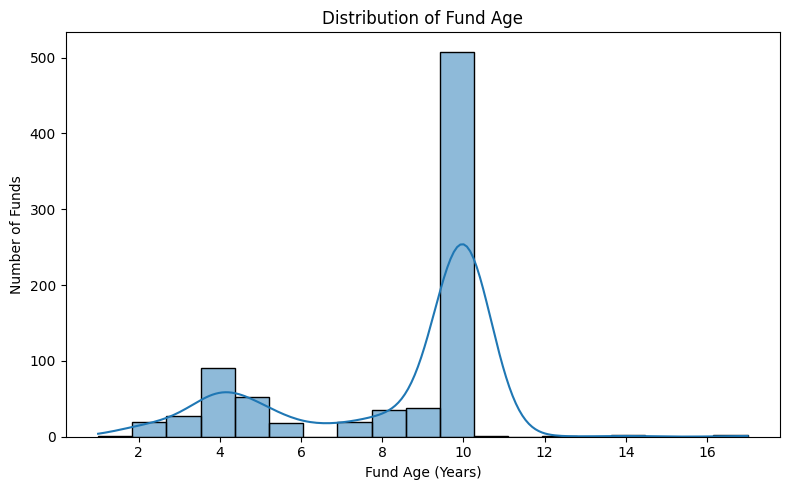

In [37]:
# Chart - 3 visualization code

plt.figure(figsize=(8, 5))
sns.histplot(df["fund_age_yr"], kde=True)
plt.title("Distribution of Fund Age")
plt.xlabel("Fund Age (Years)")
plt.ylabel("Number of Funds")
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Fund age is concentrated around approximately 10 years, with fewer very young and very old funds.
A histogram shows how fund age is distributed across the entire dataset.

##### 2. What is/are the insight(s) found from the chart?

Insights : 
Many funds are around 10 years old.
There are fewer funds at the extremes.
Fund age is not evenly distributed.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive business impact

Helps identify whether the dataset contains mostly established funds or newer schemes.

Negative-growth implication

A newer fund has less historical performance data, making long-term evaluation more difficult.

#### Chart - 4 :  FUND DISTRIBUTION BY RISK LEVEL

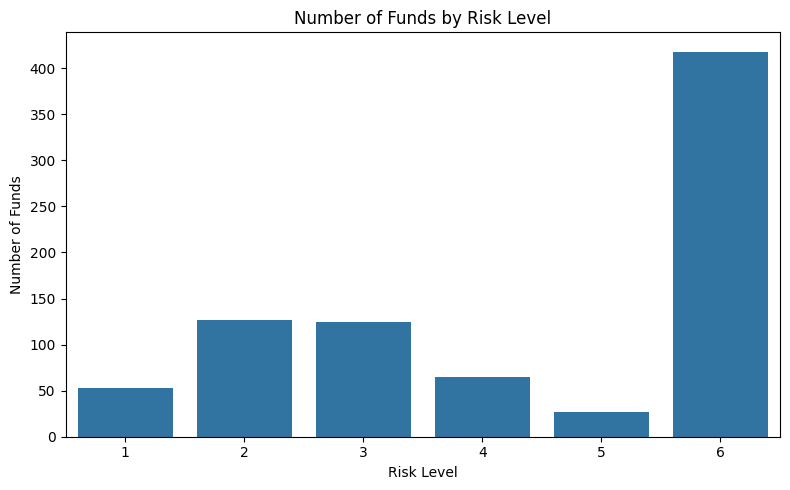

In [38]:
# Chart - 4 visualization code
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x="risk_level",
    order=sorted(df["risk_level"].dropna().unique())
)
plt.title("Number of Funds by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Number of Funds")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Risk Level 6 dominates the dataset.
A column chart makes the distribution of funds across risk categories easy to understand.

##### 2. What is/are the insight(s) found from the chart?

Distribution:

Risk 6 - 418
Risk 2 - 127
Risk 3 - 124
Risk 4 - 65
Risk 1 - 53
Risk 5 - 27

Insights : 
More than half of the funds fall into Risk Level 6.
Risk Level 5 has the fewest funds.
The dataset is heavily concentrated in Risk Level 6.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive business impact :

This helps portfolio analysts understand the risk profile of the available fund universe.

Negative-growth implication :

The concentration at Risk Level 6 means investors looking for lower-risk options have considerably fewer funds available in this dataset.

#### Chart - 5 :  FUND DISTRIBUTION BY CATEGORY

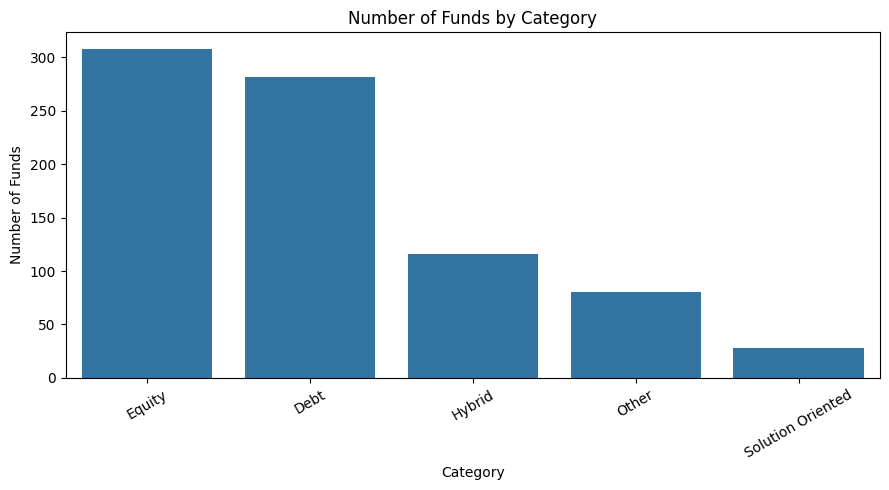

In [39]:
# Chart - 5 visualization code
plt.figure(figsize=(9, 5))
sns.countplot(
    data=df,
    x="category",
    order=df["category"].value_counts().index
)
plt.title("Number of Funds by Category")
plt.xlabel("Category")
plt.ylabel("Number of Funds")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Equity and Debt contain the largest number of funds. A bar/column chart is ideal for comparing categorical frequencies.

##### 2. What is/are the insight(s) found from the chart?

Equity has 308 funds, followed by Debt with 282, while Solution Oriented has only 28.

Insights : 
Equity represents the largest number of schemes.
Debt is almost as large as Equity.
Solution Oriented funds are relatively limited.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive business impact:

Helps businesses understand product mix and market coverage.

Negative-growth implication:

A category having many funds doesn't necessarily mean those funds have better performance.

#### Chart - 6 :  FUND DISTRIBUTION BY RATING

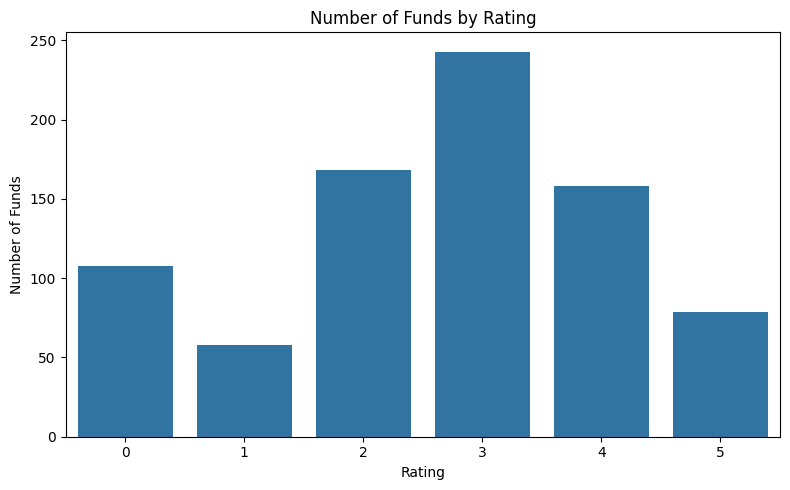

In [40]:
# Chart - 6 visualization code
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x="rating",
    order=sorted(df["rating"].dropna().unique())
)
plt.title("Number of Funds by Rating")
plt.xlabel("Rating")
plt.ylabel("Number of Funds")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Equity and Debt contain the largest number of funds. 
A bar/column chart is ideal for comparing categorical frequencies.


##### 2. What is/are the insight(s) found from the chart?

Distribution:

Equity - 308
Debt - 282
Hybrid - 116
Other - 80
Solution Oriented - 28

Insights : 
Equity represents the largest number of schemes.
Debt is almost as large as Equity.
Solution Oriented funds are relatively limited.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive business impact :

Helps businesses understand product mix and market coverage.

Negative-growth implication : 

A category having many funds doesn't necessarily mean those funds have better performance.

#### Chart - 7

In [41]:
# Chart - 7 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 8 :  3-YEAR RETURN BY CATEGORY

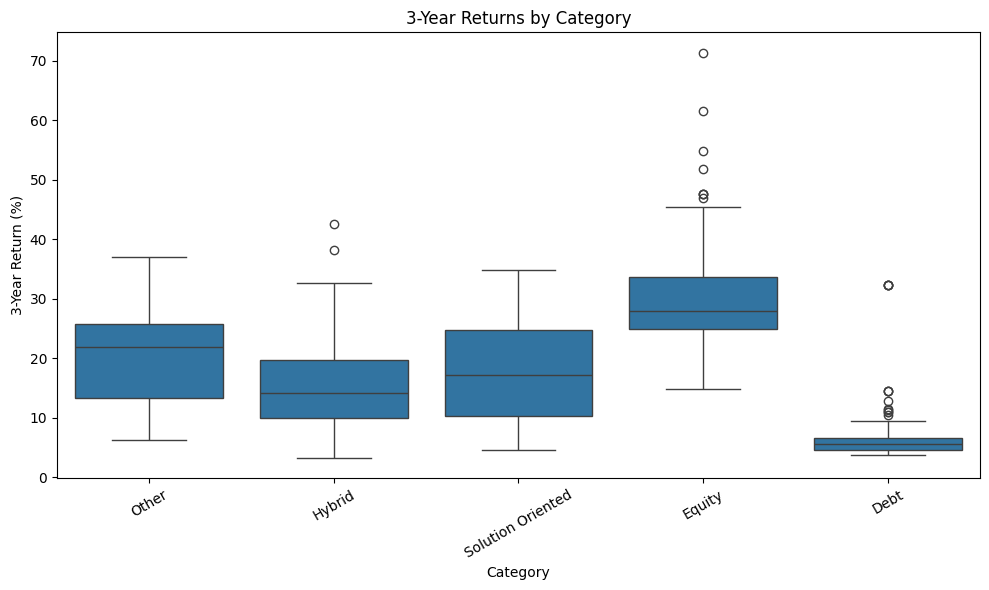

In [42]:
# Chart - 8 visualization code
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x="category",
    y="returns_3yr"
)
plt.title("3-Year Returns by Category")
plt.xlabel("Category")
plt.ylabel("3-Year Return (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Equity shows the highest 3-year return distribution, while Debt has considerably lower 3-year returns.
A box plot allows comparison of median, spread and outliers across categories.

##### 2. What is/are the insight(s) found from the chart?

| Category          | Avg 3Y Return |
| ----------------- | ------------: |
| Equity            |    **29.74%** |
| Other             |    **20.79%** |
| Solution Oriented |    **18.17%** |
| Hybrid            |    **15.27%** |
| Debt              |     **6.23%** |


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive business impact :

Helps identify categories that may warrant greater attention for long-term growth strategies.

Negative-growth implication :

Focusing heavily on Equity for its higher historical return could increase portfolio risk if diversification is ignored.

#### Chart - 9 :  1-YEAR RETURN BY RISK LEVEL

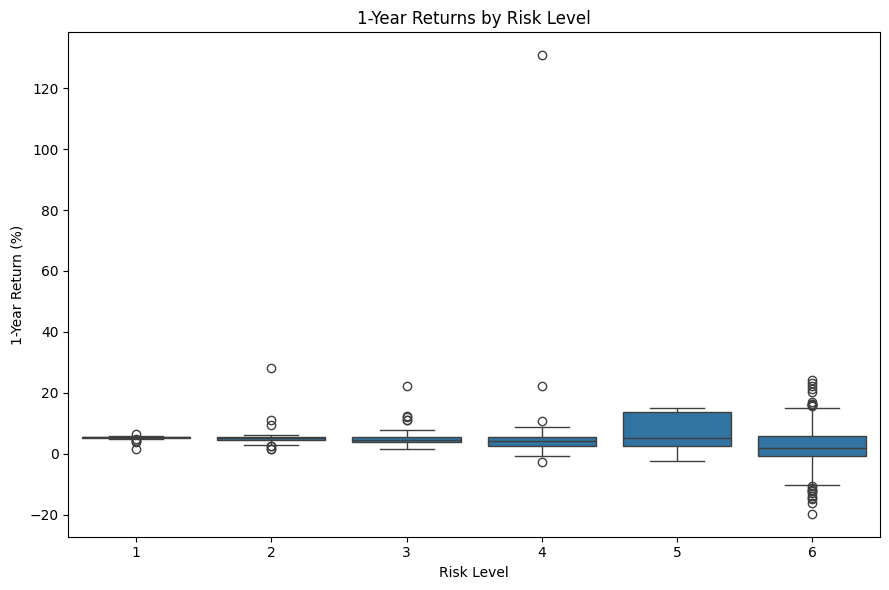

In [43]:
# Chart - 9 visualization code
plt.figure(figsize=(9, 6))
sns.boxplot(
    data=df,
    x="risk_level",
    y="returns_1yr"
)
plt.title("1-Year Returns by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("1-Year Return (%)")
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

The distribution of 1-year returns varies substantially across risk levels, with several extreme values visible.
A box plot highlights variation and outliers, which is particularly important for short-term returns.

##### 2. What is/are the insight(s) found from the chart?

Insights : 
There are significant outliers in 1-year returns.
High-risk funds can experience much wider return variations.
Short-term returns are less consistent than simply looking at category averages.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive business impact :
 
Useful for identifying funds that may require additional risk assessment before investment.

Negative-growth implication : 

Very high short-term returns can encourage performance chasing and may expose investors to greater downside risk.

#### Chart - 10 : 3-YEAR RETURN BY RISK LEVEL

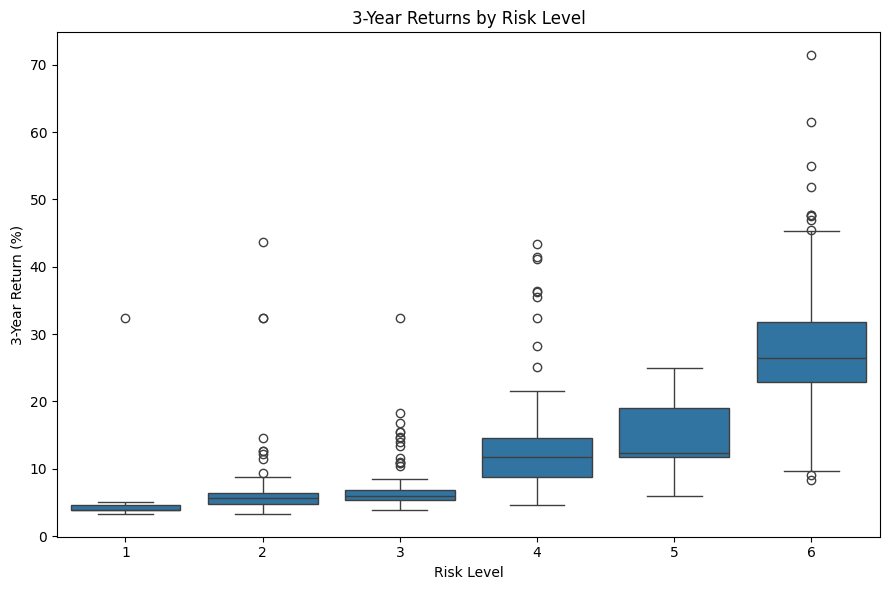

In [44]:
# Chart - 10 visualization code

plt.figure(figsize=(9, 6))
sns.boxplot(
    data=df,
    x="risk_level",
    y="returns_3yr"
)
plt.title("3-Year Returns by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("3-Year Return (%)")
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

The box plot shows how 3-year returns vary across risk levels.
A box plot is ideal because it compares the distribution of returns across multiple risk groups, not just their averages.

##### 2. What is/are the insight(s) found from the chart?

The higher-risk groups generally show greater return potential but also greater variation.

Insights :
Higher-risk funds show greater dispersion in returns.
Some higher-risk funds generate very high returns.
Lower-risk categories generally have narrower return distributions.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive business impact :

Helps investors match risk tolerance with expected return potential.

Negative-growth implication :

Higher risk can produce larger negative outcomes as well as larger positive returns.

#### Chart - 11 :  EXPENSE RATIO BY CATEGORY

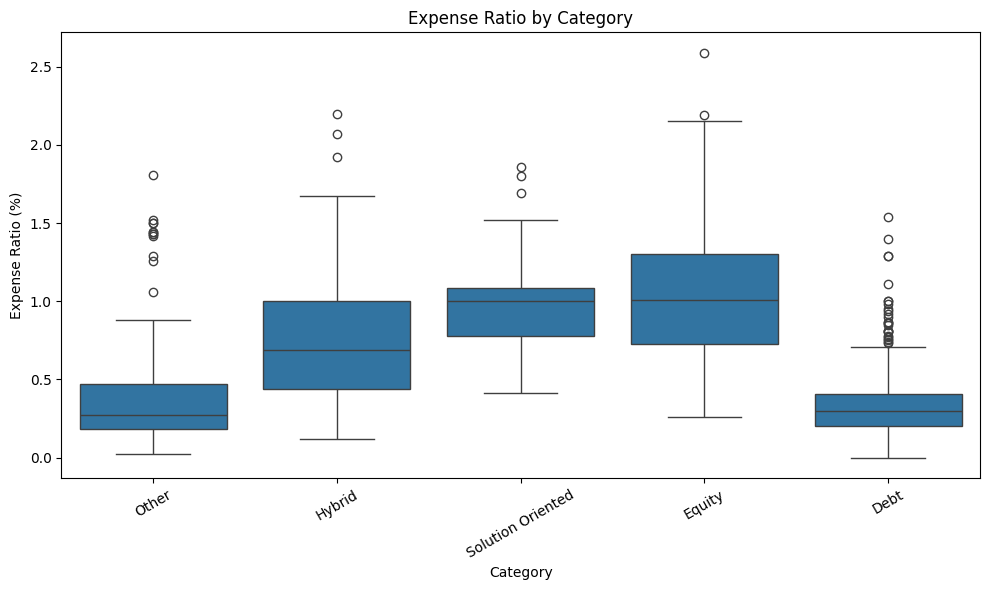

In [45]:
# Chart - 11 visualization code
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x="category",
    y="expense_ratio"
)
plt.title("Expense Ratio by Category")
plt.xlabel("Category")
plt.ylabel("Expense Ratio (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

The box plot shows differences in expense ratios across categories.

A box plot is better than a simple average because it shows:

Median, Distribution, Spread, Outliers

##### 2. What is/are the insight(s) found from the chart?

Equity: 1.05%,
Solution Oriented: 1.02%,
Hybrid: 0.78%,
Other: 0.46%,
Debt: 0.36%,

Insights : 
Equity has a relatively high expense ratio.
Debt has the lowest average expense ratio.
Some categories have wider distributions and outliers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive business impact :

Investors can compare cost efficiency across fund categories.

Negative-growth implication : 

Higher expenses can reduce investors' net returns over the long term, especially when performance differences are small.

#### Chart - 12 : AUM BY CATEGORY

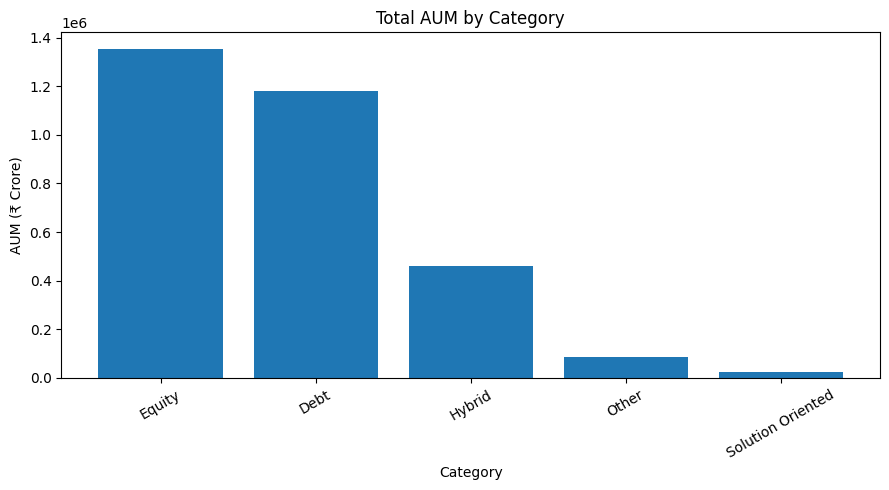

In [46]:
# Chart - 12 visualization code
aum_category = (
    df.groupby("category")["fund_size_cr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))
plt.bar(
    aum_category.index,
    aum_category.values
)
plt.title("Total AUM by Category")
plt.xlabel("Category")
plt.ylabel("AUM (₹ Crore)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Equity has the highest AUM, followed by Debt and Hybrid. A column/bar chart is appropriate for comparing total AUM across discrete categories.

##### 2. What is/are the insight(s) found from the chart?

Equity: approximately ₹13,54,230 Cr,
Debt: approximately ₹11,79,876 Cr,
Hybrid: approximately ₹4,59,225 Cr,
Other: approximately ₹86,140 Cr,
Solution Oriented: approximately ₹24,189 Cr.

Insights : 
Equity represents the largest AUM category.
Debt is also a major contributor.
Solution Oriented funds represent a very small portion of total AUM.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive business impact : 

Helps investment businesses understand where assets are concentrated and where their major product/customer exposure exists.

Negative-growth implication :

Heavy concentration in one category could increase exposure to that category's market conditions.

#### Chart - 13 : TOP 10 AMCs BY AUM

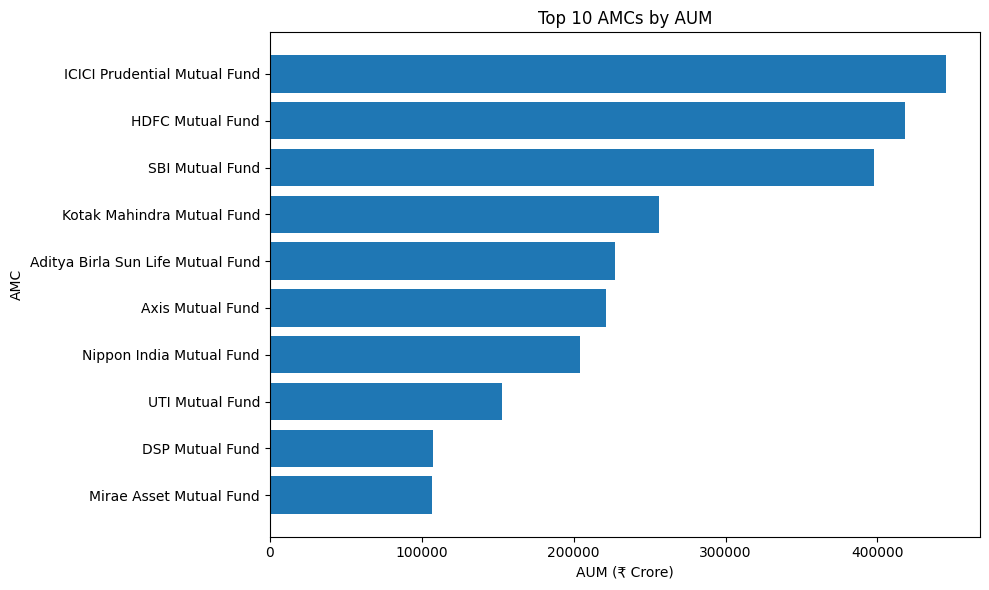

In [47]:
# Chart - 13 visualization code
amc_aum = (
    df.groupby("amc_name")["fund_size_cr"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
plt.barh(
    amc_aum.index[::-1],
    amc_aum.values[::-1]
)
plt.title("Top 10 AMCs by AUM")
plt.xlabel("AUM (₹ Crore)")
plt.ylabel("AMC")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart makes AMC rankings and differences in AUM easy to compare.

##### 2. What is/are the insight(s) found from the chart?

ICICI Prudential Mutual Fund, HDFC Mutual Fund and SBI Mutual Fund appear among the leading AMCs by AUM.

Insights : 
A few large AMCs account for substantial AUM.
ICICI Prudential appears to lead the AMCs shown.
The distribution indicates concentration of assets among major AMCs.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive business impact :

This can help stakeholders understand market concentration and major asset-management players.

Negative-growth implication :

High AUM concentration could create dependency on a small number of major AMCs and doesn't necessarily indicate better returns.

#### Chart - 14 : TOP 10 Fund Managers by AUM

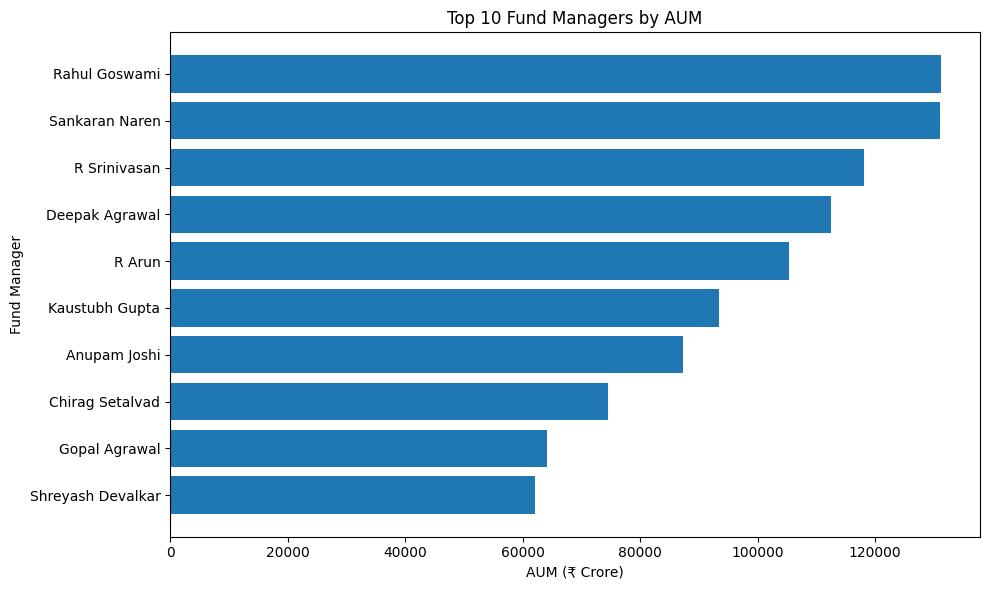

In [48]:
manager_aum = (
    df.groupby("fund_manager")["fund_size_cr"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
plt.barh(
    manager_aum.index[::-1],
    manager_aum.values[::-1]
)
plt.title("Top 10 Fund Managers by AUM")
plt.xlabel("AUM (₹ Crore)")
plt.ylabel("Fund Manager")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart is effective for comparing multiple fund managers and ranking them by AUM.

##### 2. What is/are the insight(s) found from the chart?

The chart identifies the fund managers managing the highest AUM.

The chart shows that Rahul Goswami, Sankaran Naren and R Srinivasan are among the leading fund managers by AUM.

Insights : 
A small group of fund managers manages a substantial amount of assets.
Rahul Goswami appears to have the highest AUM among the managers shown.
There is a noticeable gap between the leading managers and some of the lower-ranked managers.



##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive business impact:

This helps identify experienced/high-AUM managers for deeper due diligence and portfolio analysis.

Negative-growth implication : 

High AUM does not necessarily mean superior performance. Over-relying on AUM could result in overlooking smaller managers with stronger risk-adjusted returns.

 #### Chart - 15: TOP 10 FUNDS BY 3-YEAR RETURN


--- Top 10 Funds by 3-Year Return ---
                        scheme_name  returns_3yr category  risk_level
608            Quant Small Cap Fund         71.4   Equity           6
603       Quant Infrastructure Fund         61.5   Equity           6
609   Quant Tax Plan- Direct Growth         54.9   Equity           6
142    Canara Robeco Small Cap Fund         51.8   Equity           6
601            Quant Flexi Cap Fund         47.7   Equity           6
98     Bank of India Small Cap Fund         47.7   Equity           6
571     Nippon India Small Cap Fund         47.6   Equity           6
695  Sundaram LT Tax Advantage Fund         46.9   Equity           6
600               Quant Active Fund         45.5   Equity           6
347       ICICI Pru Technology Fund         45.3   Equity           6


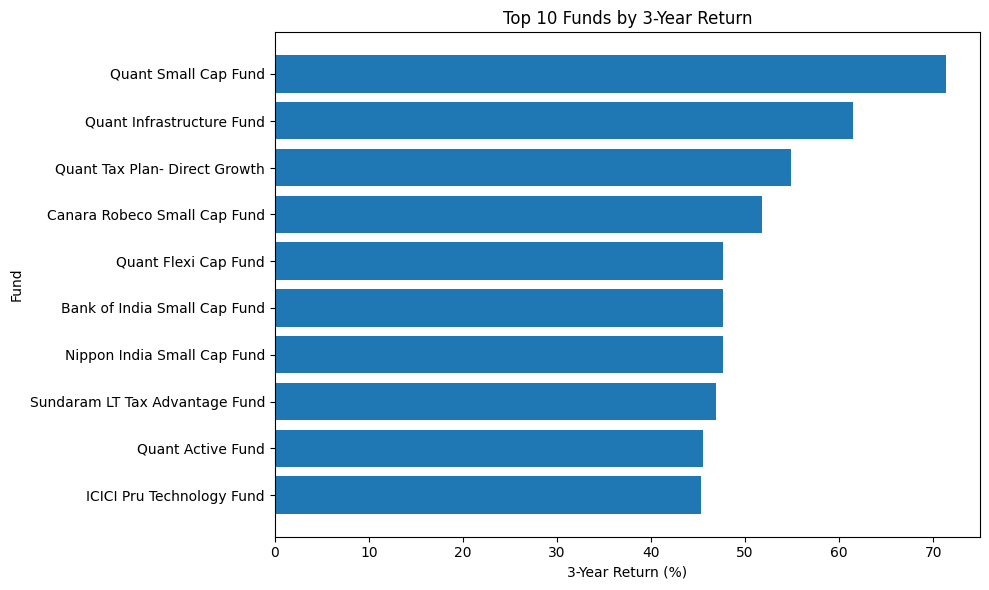

In [49]:
top_3yr = (
    df[
        [
            "scheme_name",
            "returns_3yr",
            "category",
            "risk_level"
        ]
    ]
    .dropna(subset=["returns_3yr"])
    .sort_values(
        "returns_3yr",
        ascending=False
    )
    .head(10)
)

print("\n--- Top 10 Funds by 3-Year Return ---")
print(top_3yr)


plt.figure(figsize=(10, 6))
plt.barh(
    top_3yr["scheme_name"][::-1],
    top_3yr["returns_3yr"][::-1]
)
plt.title("Top 10 Funds by 3-Year Return")
plt.xlabel("3-Year Return (%)")
plt.ylabel("Fund")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart clearly communicates ranking and magnitude.

##### 2. What is/are the insight(s) found from the chart?

The chart identifies the funds with the highest 3-year returns, led by several Quant schemes and other high-performing equity-oriented funds.

Insights : 
The top-performing funds are concentrated among a relatively small group.
Several Quant funds appear prominently among the highest 3-year performers.
The performance gap between the top funds and the broader market is meaningful.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive business impact:

This helps analysts identify funds with stronger medium-term performance for further investigation.

Negative-growth implication:

Past 3-year performance alone should not determine investment decisions because historical performance does not guarantee future performance.

#### Chart - 16: TOP 10 FUNDS BY 1-YEAR RETURN


--- Top 10 Funds by 1-Year Return ---
                                          scheme_name  returns_1yr category  \
89                     Bank of India Credit Risk Fund        130.8     Debt   
97    Bank of India Short Term Income – Direct Growth         28.3     Debt   
321                     ICICI Pru Infrastructure Fund         24.3   Equity   
451  Kotak Infrastructure & Ecoc. Reform-SP-DirGrowth         23.2   Equity   
88             Bank of India Conservative Hybrid Fund         22.3   Hybrid   
34   Aditya Birla SL Medium Term Plan – Direct Growth         22.1     Debt   
300          ICICI Pru BHARAT 22 FOF  – Direct Growth         22.1    Other   
314                               ICICI Pru FMCG Fund         21.1   Equity   
566                   Nippon India Power & Infra Fund         20.4   Equity   
741                               Tata Small Cap Fund         17.1   Equity   

     risk_level  
89            4  
97            2  
321           6  
451           6  
8

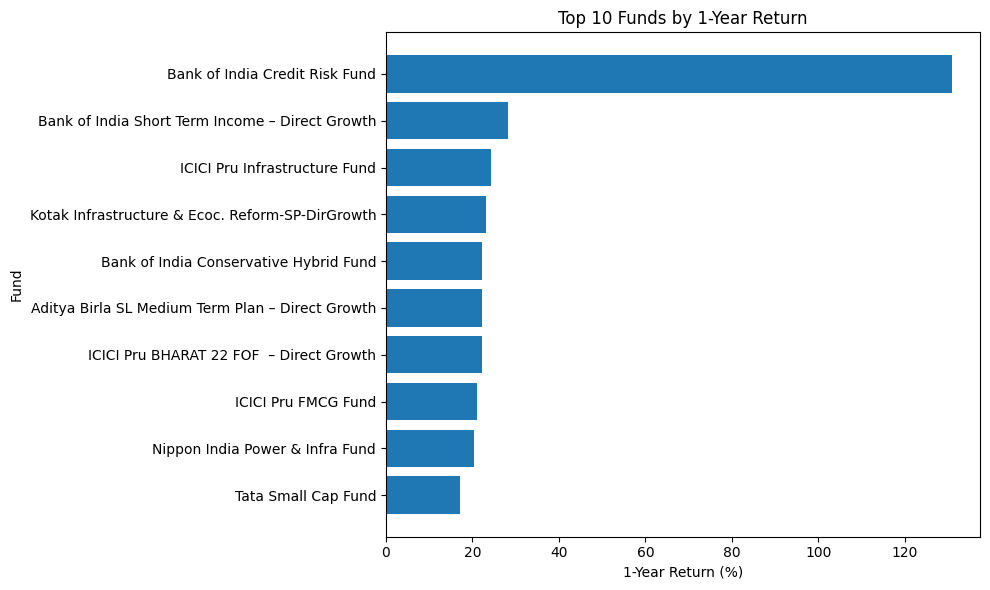

In [50]:
top_1yr = (
    df[
        [
            "scheme_name",
            "returns_1yr",
            "category",
            "risk_level"
        ]
    ]
    .sort_values(
        "returns_1yr",
        ascending=False
    )
    .head(10)
)

print("\n--- Top 10 Funds by 1-Year Return ---")
print(top_1yr)

plt.figure(figsize=(10, 6))
plt.barh(
    top_1yr["scheme_name"][::-1],
    top_1yr["returns_1yr"][::-1]
)
plt.title("Top 10 Funds by 1-Year Return")
plt.xlabel("1-Year Return (%)")
plt.ylabel("Fund")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?


A horizontal bar chart is ideal for ranking funds because fund names are long and the ranking can easily be compared.

##### 2. What is/are the insight(s) found from the chart?

The chart highlights the highest 1Y-return funds; the dataset maximum is 130.80%.

The chart identifies the 10 funds with the highest 1-year returns. A horizontal bar chart is ideal for ranking funds because fund names are long and the ranking can easily be compared.

Insights:
A small group of funds generated exceptionally high 1-year returns.
The highest-performing funds are significantly above the normal return range.
Strong short-term performance is concentrated among a relatively small number of schemes.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive business impact:

Investment analysts can use this as a short-term performance screening tool.

Negative-growth implication:

The chart should not be used alone to select funds. Extremely high 1-year returns may not persist and can expose investors to performance-chasing risk.

#### Chart - 14 : Correlation Heatmap

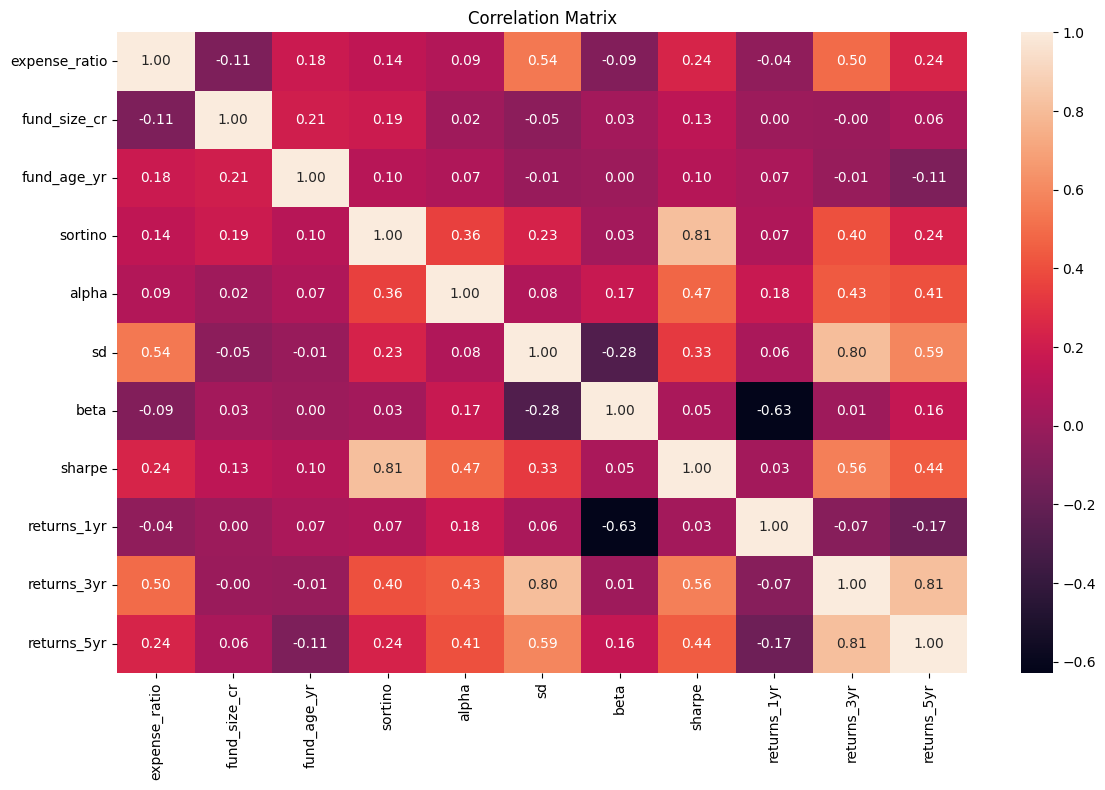

In [51]:
# Correlation Heatmap visualization code
correlation_columns = [
    "expense_ratio",
    "fund_size_cr",
    "fund_age_yr",
    "sortino",
    "alpha",
    "sd",
    "beta",
    "sharpe",
    "returns_1yr",
    "returns_3yr",
    "returns_5yr"
]

correlation_matrix = df[
    correlation_columns
].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()



##### 1. Why did you pick the specific chart?

A heatmap allows multiple variable relationships to be compared simultaneously and makes strong/weak correlations easy to identify.

##### 2. What is/are the insight(s) found from the chart?

The correlation matrix identifies relationships between returns, risk metrics, AUM, expense ratio and fund age.

Insights :

The most important relationship visible in the matrix is:

returns_3yr and returns_5yr have a relatively strong positive relationship.
Risk-adjusted measures such as Sharpe/Sortino show relationships with return metrics.
Some variables have weak relationships with returns.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive business impact :

This helps identify which variables are worth considering when developing the Fund Score and fund-selection methodology.

Negative-growth implication :

A variable with weak correlation should not automatically receive a high weight in the scoring model merely because it is available.

#### Chart - 16 : RETURN VS RISK

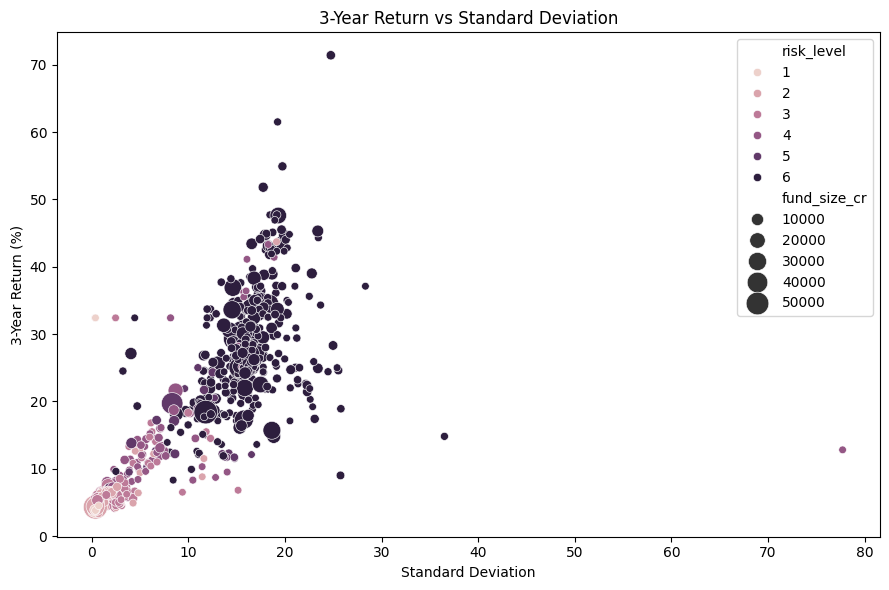

In [52]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x="sd",
    y="returns_3yr",
    hue="risk_level",
    size="fund_size_cr",
    sizes=(30, 300)
)
plt.title("3-Year Return vs Standard Deviation")
plt.xlabel("Standard Deviation")
plt.ylabel("3-Year Return (%)")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot is ideal for examining the relationship between return and risk/volatility.

##### 2. What is/are the insight(s) found from the chart?

The chart shows a positive association between 3-year returns and standard deviation. Higher-return funds are generally associated with higher volatility.

Insights:
Some of the highest-return funds also have high standard deviation.
Low-volatility funds generally show lower 3-year returns.
There are exceptions where funds achieve relatively good returns without extremely high volatility.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive business impact :

This helps investors understand the return-risk trade-off before selecting funds.

Negative-growth implication :

Chasing high-return funds without considering volatility can increase portfolio risk and potentially lead to larger losses during unfavorable market conditions.

#### Chart - 17 : SHARPE VS 3-YEAR RETURN

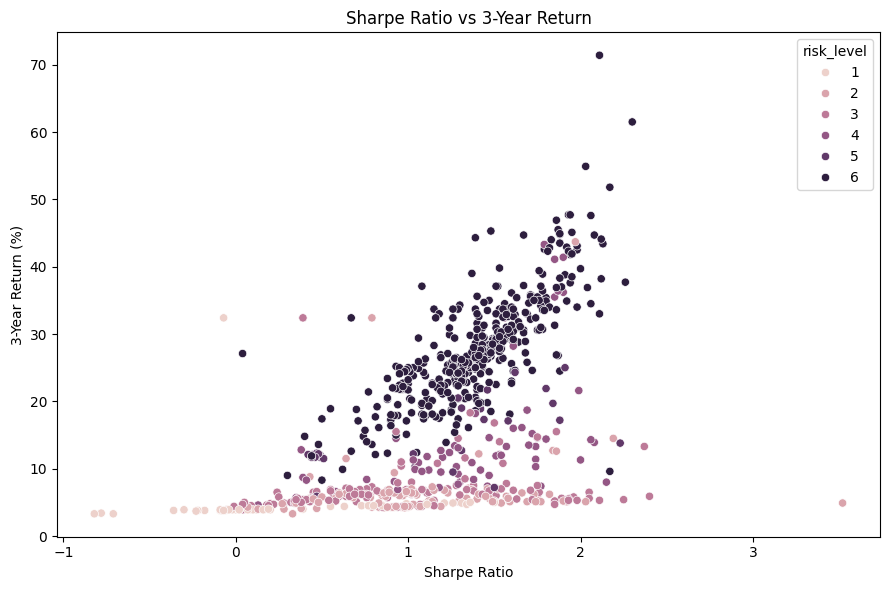

In [53]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x="sharpe",
    y="returns_3yr",
    hue="risk_level"
)
plt.title("Sharpe Ratio vs 3-Year Return")
plt.xlabel("Sharpe Ratio")
plt.ylabel("3-Year Return (%)")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot is appropriate because both Sharpe Ratio and 3-Year Return are continuous numerical variables. It helps identify relationships, clusters and unusual funds.

##### 2. What is/are the insight(s) found from the chart?

The scatter plot shows the relationship between Sharpe Ratio and 3-Year Return, with funds differentiated by risk level.

Insights :
Funds with higher Sharpe ratios generally tend to show stronger 3-year returns.
Several funds combine relatively high 3-year returns with higher Sharpe ratios.
There are also exceptions, meaning a high return does not always correspond to a high Sharpe ratio.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive business impact :

This helps investors identify funds that generate strong returns relative to the risk taken, rather than selecting funds purely on return.

Negative-growth implication :

Selecting funds purely based on high 3-year return could lead to choosing funds with poor risk-adjusted performance.

#### Chart - 18 : CATEGORY-LEVEL SUMMARY

In [54]:
category_analysis = (
    df.groupby("category")
    .agg(
        fund_count=("scheme_name", "count"),
        total_aum=("fund_size_cr", "sum"),
        avg_1yr_return=("returns_1yr", "mean"),
        avg_3yr_return=("returns_3yr", "mean"),
        avg_5yr_return=("returns_5yr", "mean"),
        avg_expense_ratio=("expense_ratio", "mean"),
        avg_sharpe=("sharpe", "mean"),
        avg_sortino=("sortino", "mean")
    )
    .sort_values(
        "avg_3yr_return",
        ascending=False
    )
)

print("\n--- Category Analysis ---")
print(category_analysis)




--- Category Analysis ---
                   fund_count  total_aum  avg_1yr_return  avg_3yr_return  \
category                                                                   
Equity                    308    1354230        2.842532       29.738111   
Other                      80      86140        2.891250       20.792405   
Solution Oriented          28      24189        1.714286       18.167857   
Hybrid                    116     459225        4.075000       15.272414   
Debt                      282    1179876        5.547872        6.228517   

                   avg_5yr_return  avg_expense_ratio  avg_sharpe  avg_sortino  
category                                                                       
Equity                  12.069767           1.054286    1.458734     3.108831  
Other                   10.710938           0.456625    1.092750     2.426250  
Solution Oriented        9.747059           1.016786    1.204286     2.589286  
Hybrid                   8.581053       

#### Chart - 19 : RISK-LEVEL SUMMARY

In [55]:

risk_analysis = (
    df.groupby("risk_level")
    .agg(
        fund_count=("scheme_name", "count"),
        avg_1yr_return=("returns_1yr", "mean"),
        avg_3yr_return=("returns_3yr", "mean"),
        avg_5yr_return=("returns_5yr", "mean"),
        avg_sharpe=("sharpe", "mean"),
        avg_sortino=("sortino", "mean"),
        avg_sd=("sd", "mean")
    )
    .sort_index()
)

print("\n--- Risk Level Analysis ---")
print(risk_analysis)



--- Risk Level Analysis ---
            fund_count  avg_1yr_return  avg_3yr_return  avg_5yr_return  \
risk_level                                                               
1                   53        5.277358        4.694340        5.445455   
2                  127        5.164567        6.662162        6.275532   
3                  124        4.900806        6.927500        6.746729   
4                   65        6.169231       14.513846        8.250909   
5                   27        7.277778       14.870370       10.356000   
6                  418        2.514833       27.640528       11.616860   

            avg_sharpe  avg_sortino     avg_sd  
risk_level                                      
1             0.337547     0.555849   0.501887  
2             1.083780     2.766693   3.220157  
3             1.016452     2.314274   3.020565  
4             1.368308     2.765077   8.050462  
5             1.133333     2.515926  10.151481  
6             1.390120     2.987536

 SAVE EDA SUMMARY

In [56]:
category_analysis.to_csv(
    "category_eda_summary.csv"
)

risk_analysis.to_csv(
    "risk_eda_summary.csv"
)

print("\nEDA completed successfully.")


EDA completed successfully.


## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

How the client can achieve the objective
1. Compare fund performance
Analyze 1Y, 3Y and 5Y returns across categories, AMCs and individual schemes.
2. Evaluate risk vs. return
Use Standard Deviation, Beta, Sharpe and Sortino ratios to identify whether higher returns are being achieved with reasonable risk.
3. Analyze cost efficiency
Compare expense ratios across categories and schemes to identify relatively cost-efficient funds.
4. Understand AUM concentration
Analyze AUM by category, AMC and fund manager to understand where assets are concentrated.
5. Create a Fund Score and ranking
Combine important performance and risk factors into a Fund Score and use it to shortlist higher-scoring schemes.
6. Provide interactive decision support
Use Power BI slicers and visuals so users can filter by category, risk level, rating, AMC and fund manager and investigate suitable funds.

Client Recommendation

I recommend using a multi-factor fund evaluation approach rather than selecting funds based only on returns. The client should consider historical returns, risk-adjusted performance, volatility, expense ratio, ratings and AUM together, and use the Power BI dashboard to compare and shortlist funds.

# **Conclusion**

The Mutual Fund Analysis project successfully transformed mutual fund data into actionable business insights by evaluating returns, risk, AUM, expense ratios, ratings, and risk-adjusted performance. The Power BI dashboard enables users to compare and rank funds and identify potentially suitable schemes using a multi-factor approach rather than relying on returns alone.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***